# Test analysis pipeline

**Dependencies**

In [1]:
### Modules importation
import re
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

**Data loading**

In [2]:
xlsx_path = "../../data/synthetic/va_ai_synthetic_bdd.xlsx"
df = pd.read_excel(xlsx_path, sheet_name="BDD", engine="openpyxl", dtype=str)

In [3]:
df.shape, df.columns.tolist()[:10]

((12494, 15),
 ["Année d'enquete",
  'Ancienneté',
  'Natio',
  'Cursus',
  'StudentType',
  'Cycle',
  'Genre',
  'AcademicLevel',
  'Campus',
  'A répondu'])

**Corpora building**

In [4]:
open_cols = [c for c in df.columns if c.startswith("Q58") or c.startswith("Q59")]
open_cols

['Q58_Quelles seraient vos suggestions d’amélioration pour l’Efrei ? ',
 'Q59_Quels autres messages souhaitez-vous adresser à l’Efrei ?']

In [5]:
def normalize_da(x) -> str:
    if x is None or (isinstance(x, float) and pd.isna(x)) or pd.isna(x):
        return ""
    s = str(x).strip()

    s_norm = re.sub(r"\s+", "", s.lower())
    if s_norm in {"d/a", "da", "n/a", "na"}:
        return ""

    return s

def clean_text(s: str) -> str:
    s = "" if s is None or pd.isna(s) else str(s)

    s = re.sub(r"_x0{3}d_", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"x0{3}d", " ", s, flags=re.IGNORECASE)

    s = s.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

corpus = (
    df[open_cols]
      .apply(lambda col: col.map(normalize_da))
      .fillna("")
      .agg(" ".join, axis=1)
      .map(clean_text)
)

### Removing empty
mask_nonempty = corpus.ne("")
corpus_clean = corpus[mask_nonempty]
idx_clean = corpus_clean.index

print("Docs non vides:", len(corpus_clean), "/", len(corpus))

Docs non vides: 3189 / 12494


In [6]:
### Non-informative filters
NON_INFO_PATTERNS = re.compile(
    r"^\s*(ras|rien|rien\s*à\s*dire|aucun|aucune|néant|neant|n/a|na|non|merci|ok)\s*$",
    re.IGNORECASE
)
is_non_info = corpus_clean.apply(lambda s: bool(NON_INFO_PATTERNS.match(s)))
print("Non-informatifs (%):", round(is_non_info.mean() * 100, 2))

corpus_thematic = corpus_clean[~is_non_info]
idx_thematic = corpus_thematic.index

print("Docs thématiques:", len(corpus_thematic))

Non-informatifs (%): 0.22
Docs thématiques: 3182


**CamemBERT embeddings**

In [7]:
import torch
from transformers import AutoTokenizer, AutoModel

EMB_MODEL = "camembert-base"

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else ("cuda" if torch.cuda.is_available() else "cpu")
)
device

/opt/miniconda3/envs/va-ai-venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='mps')

In [ ]:
tokenizer_emb = AutoTokenizer.from_pretrained(EMB_MODEL)
model_emb = AutoModel.from_pretrained(EMB_MODEL).to(device)
model_emb.eval()

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

@torch.no_grad()
def embed_texts(texts, batch_size=16, max_length=256):
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer_emb(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        out = model_emb(**enc)
        vecs = mean_pool(out.last_hidden_state, enc["attention_mask"])
        vecs = torch.nn.functional.normalize(vecs, p=2, dim=1)
        all_vecs.append(vecs.cpu().numpy())
    return np.vstack(all_vecs)

texts_thematic = corpus_thematic.astype(str).tolist()
emb = embed_texts(texts_thematic, batch_size=16, max_length=256)

emb.shape

**Topic modeling: KMeans on embeddings + “auto label”**

In [10]:
custom_sw = {"ras","rien","aucun","aucune","merci","ok","na","n","a","d","da","x000d"}

k = 20
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = km.fit_predict(emb)

np.bincount(clusters)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


array([ 2, 13, 19, 11, 13, 17,  8, 14, 10,  6, 13, 18,  6, 19,  8, 11, 16,
        4,  9, 12])

In [11]:
from nltk.corpus import stopwords

fr_sw = set(stopwords.words("french"))
extra_sw = {"x000d","da","d","a","n","na","nan","ras","rien","merci","svp","stp","sais","sait","savoir"}
stop_all = list(fr_sw | extra_sw)

In [12]:
vec = TfidfVectorizer(
    lowercase=True,
    stop_words=stop_all,
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÖØ-öø-ÿ]{3,}\b",
    ngram_range=(1,2),
    min_df=2,
    max_features=8000
)
X_tfidf = vec.fit_transform(texts_thematic)
terms = vec.get_feature_names_out()

cluster_keywords = {}
for c in range(k):
    idx = np.where(clusters == c)[0]
    mean_tfidf = X_tfidf[idx].mean(axis=0)
    top_idx = np.asarray(mean_tfidf).ravel().argsort()[-12:][::-1]
    cluster_keywords[c] = [terms[i] for i in top_idx]

for c in range(k):
    print(f"Cluster {c} ({(clusters==c).sum()} docs):", ", ".join(cluster_keywords[c][:8]))

Cluster 0 (2 docs): salles prises, ventilation, prises écrans, prises, écrans ventilation, écrans, certaines salles, certaines
Cluster 1 (13 docs): certains, plus, projets, disponibilité certains, enseignants, disponibilité, certains enseignants, proposer plus
Cluster 2 (19 docs): vraie, aimerais, ferait, ferait vraie, vraie différence, vraiment, vraiment école, école
Cluster 3 (11 docs): charge travail, charge, travail, entre cours, entre, coordination entre, coordination, expérience aimerais
Cluster 4 (13 docs): top, certains, enseignants, certains enseignants, disponibilité certains, disponibilité, continuer, continuer inviter
Cluster 5 (17 docs): problème faudrait, expérience, faudrait, améliorer expérience, trouve, posent, posent problème, problème
Cluster 6 (8 docs): projets, plus, contenus, encadrés, projets encadrés, plus contenus, pratiques projets, pratiques
Cluster 7 (14 docs): campus, plus, ambiance, ambiance campus, associations, étudiantes, associations étudiantes, propos

**Sentiment : cardiffnlp/twitter-xlm-roberta-base-sentiment**

In [13]:
from transformers import XLMRobertaTokenizer, AutoModelForSequenceClassification

SENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

tokenizer_sent = XLMRobertaTokenizer.from_pretrained(SENT_MODEL)
model_sent = AutoModelForSequenceClassification.from_pretrained(SENT_MODEL).to(device)
model_sent.eval()

id2label = model_sent.config.id2label
id2label

{0: 'negative', 1: 'neutral', 2: 'positive'}

In [14]:
@torch.no_grad()
def sentiment_proba(texts, batch_size=16, max_length=256):
    probs_all = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer_sent(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model_sent(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        probs_all.append(probs)
    return np.vstack(probs_all)

probs = sentiment_proba(texts_thematic, batch_size=16, max_length=256)
probs.shape

(229, 3)

**Assemble results + mentor-friendly aggregates**

In [15]:
results = pd.DataFrame({
    "row_id": idx_thematic,
    "verbatim": corpus_thematic.values,
    "topic_id": clusters,
    "topic_label": [" / ".join(cluster_keywords[c][:3]) for c in clusters],
    "p_neg": probs[:,0],
    "p_neu": probs[:,1],
    "p_pos": probs[:,2],
})

results["sentiment_label"] = probs.argmax(axis=1)
results["sentiment_label"] = results["sentiment_label"].map(lambda i: id2label[int(i)])
results["sentiment_score"] = results["p_pos"] - results["p_neg"]

results.head()

,row_id,verbatim,topic_id,topic_label,p_neg,p_neu,p_pos,sentiment_label,sentiment_score
0,0,"Globalement je suis satisfait, surtout pour le...",18,plus / surtout disponibilité / disponibilité,0.018100,0.037900,0.944001,positive,0.925901
1,1,"Globalement je suis satisfait, surtout pour la...",13,scolarité / administration scolarité / scolari...,0.022188,0.041526,0.936286,positive,0.914098
2,2,"Globalement je suis satisfait, surtout pour le...",11,plus / temps / tôt,0.017828,0.045864,0.936308,positive,0.918480
3,3,"Globalement je suis satisfait, surtout pour l'...",7,campus / plus / ambiance,0.019828,0.051233,0.928939,positive,0.909111
4,4,Je trouve que les emplois du temps et les déla...,3,charge travail / charge / travail,0.220060,0.193161,0.586779,positive,0.366718


In [16]:
topic_stats = (
    results.groupby(["topic_id","topic_label"])
    .agg(
        n_docs=("verbatim","size"),
        mean_sent=("sentiment_score","mean"),
        pct_neg=("sentiment_label", lambda s: (s=="negative").mean()),
    )
    .sort_values("n_docs", ascending=False)
)

print("Top thèmes (fréquence):")
display(topic_stats.head(5))

print("Top thèmes les plus négatifs:")
display(topic_stats.sort_values("mean_sent").head(5))

Top thèmes (fréquence):


,,n_docs,mean_sent,pct_neg
topic_id,topic_label,,,
2,vraie / aimerais / ferait,19,0.349033,0.105263
13,scolarité / administration scolarité / scolarité finances,19,0.919955,0.000000
11,plus / temps / tôt,18,0.923124,0.000000
5,problème faudrait / expérience / faudrait,17,-0.111478,0.529412
16,opportunités international / international / opportunités,16,0.916900,0.000000


Top thèmes les plus négatifs:


,,n_docs,mean_sent,pct_neg
topic_id,topic_label,,,
5,problème faudrait / expérience / faudrait,17,-0.111478,0.529412
15,finances ferait / communication / communication informations,11,0.345247,0.181818
2,vraie / aimerais / ferait,19,0.349033,0.105263
17,finances ferait / scolarité finances / finances,4,0.370413,0.000000
3,charge travail / charge / travail,11,0.483314,0.000000


In [17]:
meta_cols = [c for c in ["Campus","Academic level","Genre","Date de réponse"] if c in df.columns]

results_enriched = results.merge(
    df[meta_cols],
    left_on="row_id",
    right_index=True,
    how="left"
)

# results_enriched = results_enriched.loc[idx_clean].copy()
results_enriched["verbatim_clean"] = corpus_clean
results_enriched["verbatim_raw"] = results_enriched["verbatim"]
results_enriched["verbatim"] = results_enriched["verbatim_clean"]

results_enriched.head()

,row_id,verbatim,topic_id,topic_label,p_neg,p_neu,p_pos,sentiment_label,sentiment_score,Campus,Academic level,Genre,Date de réponse,verbatim_clean,verbatim_raw
0,0,"Globalement je suis satisfait, surtout pour le...",18,plus / surtout disponibilité / disponibilité,0.018100,0.037900,0.944001,positive,0.925901,Villejuif,Bachelor 1,H,09/12/2025,"Globalement je suis satisfait, surtout pour le...","Globalement je suis satisfait, surtout pour le..."
1,1,"Globalement je suis satisfait, surtout pour la...",13,scolarité / administration scolarité / scolari...,0.022188,0.041526,0.936286,positive,0.914098,Bordeaux,Ingénieur 1A,F,06/10/2025,"Globalement je suis satisfait, surtout pour la...","Globalement je suis satisfait, surtout pour la..."
2,2,"Globalement je suis satisfait, surtout pour le...",11,plus / temps / tôt,0.017828,0.045864,0.936308,positive,0.918480,Villejuif,M1,H,18/11/2025,"Globalement je suis satisfait, surtout pour le...","Globalement je suis satisfait, surtout pour le..."
3,3,"Globalement je suis satisfait, surtout pour l'...",7,campus / plus / ambiance,0.019828,0.051233,0.928939,positive,0.909111,Bordeaux,Bachelor 3,H,08/10/2025,"Globalement je suis satisfait, surtout pour l'...","Globalement je suis satisfait, surtout pour l'..."
4,4,Je trouve que les emplois du temps et les déla...,3,charge travail / charge / travail,0.220060,0.193161,0.586779,positive,0.366718,Bordeaux,Bachelor 2,F,14/12/2025,Je trouve que les emplois du temps et les déla...,Je trouve que les emplois du temps et les déla...


**Average sentiment by campus**

In [18]:
sent_by_campus = (results_enriched
    .groupby("Campus")
    .agg(n=("verbatim","size"), mean_sent=("sentiment_score","mean"), pct_neg=("sentiment_label", lambda s: (s=="negative").mean()))
    .sort_values("n", ascending=False)
)
sent_by_campus

,n,mean_sent,pct_neg
Campus,,,
Bordeaux,122,0.700113,0.065574
Villejuif,107,0.735404,0.046729


**Top 3 themes by campus**

In [19]:
top_topics_by_campus = (results_enriched
    .groupby(["Campus","topic_id","topic_label"])
    .size()
    .reset_index(name="n_docs")
    .sort_values(["Campus","n_docs"], ascending=[True, False])
    .groupby("Campus")
    .head(5)
)
top_topics_by_campus

,Campus,topic_id,topic_label,n_docs
1,Bordeaux,2,vraie / aimerais / ferait,13
0,Bordeaux,1,certains / plus / projets,10
10,Bordeaux,11,plus / temps / tôt,10
15,Bordeaux,16,opportunités international / international / o...,10
4,Bordeaux,5,problème faudrait / expérience / faudrait,8
32,Villejuif,13,scolarité / administration scolarité / scolari...,11
24,Villejuif,5,problème faudrait / expérience / faudrait,9
26,Villejuif,7,campus / plus / ambiance,9
29,Villejuif,10,outils numériques / numériques / numériques mo...,8
30,Villejuif,11,plus / temps / tôt,8


**Most negative themes by campus**

In [20]:
neg_topics_by_campus = (results_enriched
    .groupby(["Campus","topic_id","topic_label"])
    .agg(n_docs=("verbatim","size"), mean_sent=("sentiment_score","mean"))
    .reset_index()
    .sort_values(["Campus","mean_sent"], ascending=[True, True])
    .groupby("Campus")
    .head(5)
)
neg_topics_by_campus

,Campus,topic_id,topic_label,n_docs,mean_sent
4,Bordeaux,5,problème faudrait / expérience / faudrait,8,-0.056260
14,Bordeaux,15,finances ferait / communication / communicatio...,7,0.159028
1,Bordeaux,2,vraie / aimerais / ferait,13,0.329025
16,Bordeaux,17,finances ferait / scolarité finances / finances,2,0.331833
2,Bordeaux,3,charge travail / charge / travail,7,0.486911
24,Villejuif,5,problème faudrait / expérience / faudrait,9,-0.160560
21,Villejuif,2,vraie / aimerais / ferait,6,0.392385
36,Villejuif,17,finances ferait / scolarité finances / finances,2,0.408993
22,Villejuif,3,charge travail / charge / travail,4,0.477018
29,Villejuif,10,outils numériques / numériques / numériques mo...,8,0.551703


**Detect suggestions/requests**

In [21]:
ACTION_PAT = re.compile(r"\b(il faudrait|je sugg[eè]re|ce serait (top|bien)|j'aimerais|il faut|am[eé]liorer|renforcer|clarifier|mettre en place)\b", re.IGNORECASE)

results_enriched["is_actionable"] = results_enriched["verbatim"].apply(lambda s: bool(ACTION_PAT.search(str(s))))

actionable_rate = results_enriched["is_actionable"].mean()
actionable_rate

np.float64(0.9126637554585153)

In [22]:
actionable_topics = (results_enriched[results_enriched["is_actionable"]]
    .groupby(["topic_id","topic_label"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
actionable_topics

topic_id  topic_label                                              
2         vraie / aimerais / ferait                                    17
13        scolarité / administration scolarité / scolarité finances    17
11        plus / temps / tôt                                           17
5         problème faudrait / expérience / faudrait                    16
16        opportunités international / international / opportunités    15
7         campus / plus / ambiance                                     14
4         top / certains / enseignants                                 13
10        outils numériques / numériques / numériques moodle           12
1         certains / plus / projets                                    11
19        prises / moderniser certaines / prises écrans                11
dtype: int64

---

### Visualizations

**Bar chart : Top themes**

In [23]:
import plotly.express as px

df_top = topic_stats.reset_index().sort_values("n_docs", ascending=False).head(15)

fig = px.bar(
    df_top,
    x="n_docs",
    y="topic_label",
    orientation="h",
    title="Top thèmes (volume)",
    hover_data=["mean_sent", "pct_neg"]
)
fig.show()

**Bar chart: Top most negative themes**

In [24]:
df_neg = topic_stats.reset_index().sort_values("mean_sent", ascending=True).head(15)

fig = px.bar(
    df_neg,
    x="mean_sent",
    y="topic_label",
    orientation="h",
    title="Thèmes les plus négatifs (sentiment moyen)",
    hover_data=["n_docs", "pct_neg"]
)
fig.show()

**Scatter “prioritization”: frequency & negativity**

In [25]:
df_p = topic_stats.reset_index().copy()

fig = px.scatter(
    df_p,
    x="n_docs",
    y="mean_sent",
    size="n_docs",
    hover_data=["topic_label", "pct_neg"],
    title="Priorisation : volume vs négativité",
)
fig.update_yaxes(autorange="reversed")
fig.show()

**Heatmap: topics by campus (top 10)**

In [26]:
top10_labels = (
    topic_stats.reset_index()
    .sort_values("n_docs", ascending=False)
    .head(10)["topic_label"]
    .tolist()
)

heat = (results_enriched[results_enriched["topic_label"].isin(top10_labels)]
    .groupby(["Campus","topic_label"])
    .size()
    .reset_index(name="n_docs")
)

pivot = heat.pivot(index="Campus", columns="topic_label", values="n_docs").fillna(0)

fig = px.imshow(
    pivot,
    title="Thèmes (Top 10) par campus (volume)",
    aspect="auto"
)
fig.show()

**Sentiment distribution by campus**

In [27]:
camp = results_enriched.groupby(["Campus","sentiment_label"]).size().reset_index(name="n")

fig = px.bar(
    camp, x="Campus", y="n", color="sentiment_label",
    title="Répartition des sentiments par campus",
    barmode="group"
)
fig.show()

**Word cloud by topic**

In [28]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

CUSTOM_STOP = {
    "de","et","les","des","pour","je","j","le","la","un","une","du","au","aux",
    "ce","cette","ces","dans","sur","avec","plus","tout",
    "globalement","satisfait","satisfaite","satisfaction",
    "suggere","suggère","serait","top","merci",
    "efrei","ecole","école"
}

def plot_wordcloud_for_topic(results_df, topic_id=None, max_words=120):
    sub = results_df[results_df["topic_id"] == topic_id]
    text = " ".join(sub["verbatim"].astype(str).tolist()).strip()
    if not text:
        print("No text")
        return

    wc = WordCloud(
        width=1000, height=500,
        background_color="white",
        max_words=max_words,
        stopwords=set(STOPWORDS) | CUSTOM_STOP,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud Topic {topic_id}")
    plt.show()


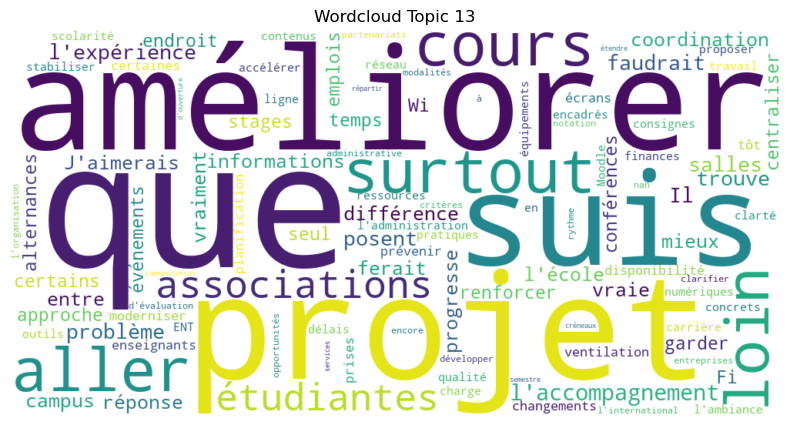

In [29]:
### Example: most common topic
top_topic_id = topic_stats.reset_index().sort_values("n_docs", ascending=False).iloc[1]["topic_id"]
plot_wordcloud_for_topic(results_enriched, topic_id=int(top_topic_id))

In [30]:
###
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def show_examples(results_df, topic_id, n=3):
    sub = results_df[results_df["topic_id"] == topic_id]
    if len(sub) == 0:
        return sub

    sub = sub.sample(min(n, len(sub)), random_state=42)

    campus_col = pick_col(results_df, ["Campus", "campus"])
    level_col  = pick_col(results_df, ["AcademicLevel", "Academic level", "Academic_level", "Niveau", "Academic level "])

    cols = ["verbatim", "sentiment_label", "sentiment_score"]
    if campus_col: cols.append(campus_col)
    if level_col:  cols.append(level_col)

    return sub[cols]

show_examples(results_enriched, int(top_topic_id), n=3)

,verbatim,sentiment_label,sentiment_score,Campus,Academic level
1,"Globalement je suis satisfait, surtout pour la...",positive,0.914098,Bordeaux,Ingénieur 1A
44,Je trouve que les salles et équipements et l'o...,positive,0.911987,Villejuif,Ingénieur 2A
91,"Globalement je suis satisfait, surtout pour le...",positive,0.921516,Villejuif,CPI1


In [31]:
results_enriched.columns

Index(['row_id', 'verbatim', 'topic_id', 'topic_label', 'p_neg', 'p_neu',
       'p_pos', 'sentiment_label', 'sentiment_score', 'Campus',
       'Academic level', 'Genre', 'Date de réponse', 'verbatim_clean',
       'verbatim_raw', 'is_actionable'],
      dtype='object')

---

### Export Parquet

In [32]:
# =========================
# Config export
# =========================
RUN_NAME = "run_2026-01-16"
OUT_DIR = Path("../../data/processed") / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = OUT_DIR / "results.parquet"
AGGS_PATH = OUT_DIR / "aggregates.parquet"

In [33]:
# =========================
# 1) Export verbatim-level
# =========================
results_enriched.to_parquet(RESULTS_PATH, index=False)
print("Saved:", RESULTS_PATH)

Saved: ../../data/processed/run_2026-01-16/results.parquet


In [34]:
results_enriched.columns

Index(['row_id', 'verbatim', 'topic_id', 'topic_label', 'p_neg', 'p_neu',
       'p_pos', 'sentiment_label', 'sentiment_score', 'Campus',
       'Academic level', 'Genre', 'Date de réponse', 'verbatim_clean',
       'verbatim_raw', 'is_actionable'],
      dtype='object')

In [35]:
sent_by_level = (results_enriched
    .groupby("Academic level")
    .agg(
        n=("verbatim","size"),
        mean_sent=("sentiment_score","mean"),
        pct_neg=("sentiment_label", lambda s: (s=="negative").mean()),
    )
    .sort_values("n", ascending=False)
    .reset_index()
)

sent_by_genre = (results_enriched
    .groupby("Genre")
    .agg(
        n=("verbatim","size"),
        mean_sent=("sentiment_score","mean"),
        pct_neg=("sentiment_label", lambda s: (s=="negative").mean()),
    )
    .sort_values("n", ascending=False)
    .reset_index()
)

In [36]:
# =========================
# 2) Export aggregates
# =========================
aggs = {
    ### Global topics
    "topic_stats": topic_stats.reset_index(drop=True),

    ### Feeling by dimensions
    "sent_by_campus": sent_by_campus.reset_index(drop=True) if "sent_by_campus" in globals() else None,
    "sent_by_level": sent_by_level.reset_index(drop=True) if "sent_by_level" in globals() else None,
    "sent_by_genre": sent_by_genre.reset_index(drop=True) if "sent_by_genre" in globals() else None,

    ### Top themes by dimensions
    "top_topics_by_campus": top_topics_by_campus.reset_index(drop=True) if "top_topics_by_campus" in globals() else None,
    "neg_topics_by_campus": neg_topics_by_campus.reset_index(drop=True) if "neg_topics_by_campus" in globals() else None,
}

In [37]:
### Cleaning
aggs = {k: v for k, v in aggs.items() if v is not None}

agg_frames = []
for name, df_ in aggs.items():
    tmp = df_.copy()
    tmp.insert(0, "table", name)
    agg_frames.append(tmp)

aggregates = pd.concat(agg_frames, ignore_index=True, sort=False)

In [38]:
aggregates.to_parquet(AGGS_PATH, index=False)
print("Saved:", AGGS_PATH)

print("\nExport done. Files:")
print(" -", RESULTS_PATH)
print(" -", AGGS_PATH)
print("Tables in aggregates:", list(aggs.keys()))

Saved: ../../data/processed/run_2026-01-16/aggregates.parquet

Export done. Files:
 - ../../data/processed/run_2026-01-16/results.parquet
 - ../../data/processed/run_2026-01-16/aggregates.parquet
Tables in aggregates: ['topic_stats', 'sent_by_campus', 'sent_by_level', 'sent_by_genre', 'top_topics_by_campus', 'neg_topics_by_campus']
